# Uncertainty Quantification Models

A **Deep Ensemble** is a collection of neural networks with identical architecture that are initialized at different random states.

**Monte Carlo Dropout** applies neuron dropout during both tuning (exactly as _normal dropout_) and during fitting, meaning each pass always has neurons deactivated.

## Import

In [28]:
from matplotlib import pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import copy
import time
import os

import pyMAISE as mai
from pyMAISE.preprocessing import train_test_split, scale_data
from pyMAISE.datasets import load_BWR, load_chf

RETUNE = False
RESULTS_FILES = {
    "BWR": "results/uq_bwr_results.joblib",
    "CHF": "results/uq_chf_results.joblib",
}

# Plot settings
matplotlib_settings = {
    "font.size": 12,
    "legend.fontsize": 11,
    "figure.figsize": (8, 8)
}
plt.rcParams.update(**matplotlib_settings)

## Initialize pyMAISE

In [29]:
mai.init(
    problem_type=mai.ProblemType.REGRESSION,
    random_state=24,
    verbosity=0,                # Hides warnings
    # cuda_visible_devices="2"  # Uncomment if errors using GPU
)

## Load Datasets

The two uncertainty quantification (UQ) models will be demonstrated using two different datasets: a single-output and a multi-output dataset.


### Single-output: Critical Heat Flux (CHF)

**Inputs**

- `D (m)`: Diameter of the test section ($0.002 - 0.016~m$)
- `L (m)`: Heated length ($0.07 - 15.0~m$)
- `P (kPa)`: Pressure ($100 - 20,000~kPa$)
- `G (kg m-2s-1)`: Mass flux ($17.7 - 7712.0~\frac{kg}{m^2\cdot s}$)
- `Tin (C)`: Inlet temperature length ($9.0 - 353.62 ^\circ C$)
- `Xe (-)`: Outlet equilibrium quality ($-0.445 - 0.986$)

**Output**

- `CHF (kW m-2)`: Critical heat flux ($130.0 - 13345.0~\frac{kW}{m^2}$)


### Multi-output: Boiling Water Reactor (BWR) Micro Core

**Inputs**

- `PSZ`: Fuel bundle region Power Shaping Zone (PSZ).
- `DOM`:  Fuel bundle region Dominant zone (DOM).
- `vanA`: Fuel bundle region vanishing zone A (VANA).
- `vanB`: Fuel bundle region vanishing zone B (VANB)
- `subcool`: Represents moderator inlet conditions. Core inlet subcooling is interpreted as at the steam dome pressure (i.e., not core-averaged pressure). The input value for subcooling will automatically be increased to account for this fact. (Btu/lb)?
- `CRD`: Defines the position of all control rod groups (banks).
- `flow_rate`: Defines essential global design data for rated coolant mass flux for the active core, $\frac{kg}{(cm^{2}-hr)}$. Coolant   mass flux equals active core flow divided by core cross-section area. The core cross-section area is DXA 2 times the number of assemblies.
- `power_density`: Defines essential global design data for rated power density using cold dimensions, $(\frac{kw}{liter})$.
- `VFNGAP`: Defines the narrow water gap width ratio to the sum of the narrow and wide water gap widths.

**Output**

- `K-eff`:  Reactivity coefficient k-effective, the effective neutron multiplication factor.
- `Max3Pin`: Maximum planar-averaged pin power peaking factor.
- `Max4Pin`: maximum pin-power peaking factor, $F_{q}$, (which includes axial intranodal peaking).
- `F-delta-H`: Ratio of max-to-average enthalpy rises in a channel.
- `Max-Fxy`: Maximum radial pin-power peaking factor.

In [30]:
# Load BWR dataset
data_bwr, inputs_bwr, outputs_bwr = load_BWR()
xtrain_bwr, xtest_bwr, ytrain_bwr, ytest_bwr = train_test_split(
    data=[inputs_bwr, outputs_bwr],
    test_size=0.3,
)
xtrain_bwr, xtest_bwr, xscaler_bwr = scale_data(xtrain_bwr, xtest_bwr, scaler=MinMaxScaler())
ytrain_bwr, ytest_bwr, yscaler_bwr = scale_data(ytrain_bwr, ytest_bwr, scaler=MinMaxScaler())

# Load CHF dataset
_, xtrain_chf, ytrain_chf, _, xtest_chf, ytest_chf = load_chf()
xtrain_chf, xtest_chf, xscaler_chf = scale_data(xtrain_chf, xtest_chf, scaler=MinMaxScaler())
ytrain_chf, ytest_chf, yscaler_chf = scale_data(ytrain_chf, ytest_chf, scaler=MinMaxScaler())

## Model Initialization

Different base hyperparameters will be used for the two different datasets.

UQ models introduce a new unique parameter that correlates to how the model measures uncertainty. The models also require specific existing parameters to be set to a specific value.

### Deep Ensemble (DE)
- `num_models`: The number of members in the ensemble, which are used to measure total model disagreement (epistemic uncertainty).
- `compile_params.loss`: For data noise (aleatoric uncertainty), the _Negative Log Likelihood_ (NLL) loss function must be used: `"nll"`
  - `Dense_output.units`: **MUST** be set to $2 \times $ the number of outputs when using the NLL loss function.

### Monte Carlo Dropout (MCD)
- `num_passes`: The number of forward passes the model will make with dropout enabled to make a prediction.
- `structural_params.Dense_hidden.sublayer`: Set to `"Dropout"` to enable dropout.
- `structural_params.Dense_hidden.Dropout.rate`: The dropout rate. `0.2` is a good starting point.

In [31]:
# BWR Configuration
bwr_base_nn_params = {
    "optimizer": "Adam",
    "Adam": {
        "learning_rate": 1e-3,
    },
    "fitting_params": {
        "batch_size": 32,
        "epochs": 50,
        "validation_split": 0.15,
    },
}

bwr_model_settings = {
    "models": ["DE", "MCD"],
    "DE": {
        "num_models": 10,
        "structural_params": {
            "Dense_hidden": {
                "num_layers": 2,
                "units": 64,
                "activation": "relu",
                "sublayer": "None",
            },
            "Dense_output": {
                "units": ytrain_bwr.shape[-1] * 2,
                "activation": "linear",
            },
        },
        "compile_params": {
            "loss": "nll",
        },
        **copy.deepcopy(bwr_base_nn_params),
    },
    "MCD": {
        "num_passes": 200,
        "structural_params": {
            "Dense_hidden": {
                "num_layers": 2,
                "units": 64,
                "activation": "relu",
                "sublayer": "Dropout",
                "Dropout": {
                    "rate": 0.2,
                },
            },
            "Dense_output": {
                "units": ytrain_bwr.shape[-1],
                "activation": "linear",
            },
        },
        "compile_params": {
            "loss": "mse",
        },
        **copy.deepcopy(bwr_base_nn_params),
    },
}

# CHF Configuration
chf_base_nn_params = {
    "optimizer": "Adam",
    "Adam": {
        "learning_rate": 1e-3,
    },
    "fitting_params": {
        "batch_size": 32,
        "epochs": 15,
        "validation_split": 0.15,
    },
}

chf_model_settings = {
    "models": ["DE", "MCD"],
    "DE": {
        "num_models": 10,
        "structural_params": {
            "Dense_hidden": {
                "num_layers": 2,
                "units": 64,
                "activation": "relu",
                "sublayer": "None",
            },
            "Dense_output": {
                "units": ytrain_chf.shape[-1] * 2,
                "activation": "linear",
            },
        },
        "compile_params": {
            "loss": "nll",
        },
        **copy.deepcopy(chf_base_nn_params),
    },
    "MCD": {
        "num_passes": 200,
        "structural_params": {
            "Dense_hidden": {
                "num_layers": 2,
                "units": 64,
                "activation": "relu",
                "sublayer": "Dropout",
                "Dropout": {
                    "rate": 0.2,
                },
            },
            "Dense_output": {
                "units": ytrain_chf.shape[-1],
                "activation": "linear",
            },
        },
        "compile_params": {
            "loss": "mse",
        },
        **copy.deepcopy(chf_base_nn_params),
    },
}

## Hyperparameter Tuning

Since two datasets are being used, there are two tuners.

In [32]:
bwr_tuner = mai.Tuner(xtrain_bwr, ytrain_bwr, model_settings=bwr_model_settings)
chf_tuner = mai.Tuner(xtrain_chf, ytrain_chf, model_settings=chf_model_settings)
results = {}

tuner_params = {
    "objective": "r2_score",
    "n_trials": 50,
    "cv": 5,
}

if RETUNE:
    start = time.time()
    for r, f_path in RESULTS_FILES.items():
        tuner = bwr_tuner if r == "BWR" else chf_tuner
        results[r] = tuner.nn_bayesian_search(**tuner_params)
        print(f"Hyperparameter for {r} tuning took {(time.time() - start) / 60:.2f} minutes to process.")

        os.makedirs(os.path.dirname(f_path), exist_ok=True)
        mai.save_tuning_results(f_path, results[r], tuner=tuner)
else:
    results = {
        "BWR": mai.load_tuning_results(RESULTS_FILES["BWR"], tuner=bwr_tuner),
        "CHF": mai.load_tuning_results(RESULTS_FILES["CHF"], tuner=chf_tuner),
    }

## Instantiate Post Processors and Display Metrics

In [33]:
pp_bwr = mai.PostProcessor(
    data=(xtrain_bwr, xtest_bwr, ytrain_bwr, ytest_bwr),
    model_configs=[results["BWR"]],
    new_model_settings={
        "DE": {"fitting_params": {"epochs": 200}},
        "MCD": {"fitting_params": {"epochs": 200}},
    },
    yscaler=yscaler_bwr,
)
pp_bwr.metrics().drop("Parameter Configurations", axis=1)

,Model Types,Train R2,Train MAE,Train MAPE,Train RMSE,Train RMSPE,Test R2,Test MAE,Test MAPE,Test RMSE,Test RMSPE
6,MCD,0.881430,0.092494,2.399277,0.254515,4.507174,0.849160,0.094819,2.429414,0.259304,4.635613
9,MCD,0.868063,0.098460,2.611881,0.264103,4.738866,0.847809,0.102228,2.669952,0.270076,4.856855
7,MCD,0.854688,0.095943,2.551515,0.261165,4.655610,0.846518,0.100948,2.635906,0.271273,4.823301
5,MCD,0.854245,0.100906,2.502736,0.280792,4.733518,0.845479,0.105934,2.588421,0.287841,4.803788
8,MCD,0.847029,0.095674,2.588821,0.263771,4.943026,0.839685,0.095879,2.584791,0.260288,4.935237
0,DE,0.828030,0.108066,2.565339,0.360189,6.129377,0.834596,0.097272,2.310191,0.321270,5.369108
1,DE,0.828030,0.108066,2.565339,0.360189,6.129377,0.834596,0.097272,2.310191,0.321270,5.369108
2,DE,0.828030,0.108066,2.565339,0.360189,6.129377,0.834596,0.097272,2.310191,0.321270,5.369108
3,DE,0.828030,0.108066,2.565339,0.360189,6.129377,0.834596,0.097272,2.310191,0.321270,5.369108
4,DE,0.828030,0.108066,2.565339,0.360189,6.129377,0.834596,0.097272,2.310191,0.321270,5.369108


In [34]:
pp_chf = mai.PostProcessor(
    data=(xtrain_chf, xtest_chf, ytrain_chf, ytest_chf),
    model_configs=[results["CHF"]],
    new_model_settings={
        "DE": {"fitting_params": {"epochs": 200}},
        "MCD": {"fitting_params": {"epochs": 200}},
    },    yscaler=yscaler_chf,
)
pp_chf.metrics().drop("Parameter Configurations", axis=1)

,Model Types,Train R2,Train MAE,Train MAPE,Train RMSE,Train RMSPE,Test R2,Test MAE,Test MAPE,Test RMSE,Test RMSPE
0,DE,0.976591,117.813831,7.196317,222.404775,12.069942,0.975373,124.509004,7.257597,209.048456,11.029727
1,DE,0.976591,117.813831,7.196317,222.404775,12.069942,0.975373,124.509004,7.257597,209.048456,11.029727
2,DE,0.976591,117.813831,7.196317,222.404775,12.069942,0.975373,124.509004,7.257597,209.048456,11.029727
3,DE,0.976591,117.813831,7.196317,222.404775,12.069942,0.975373,124.509004,7.257597,209.048456,11.029727
4,DE,0.976591,117.813831,7.196317,222.404775,12.069942,0.975373,124.509004,7.257597,209.048456,11.029727
8,MCD,0.967950,206.187146,23.543797,260.232648,39.127964,0.966325,200.774589,21.403831,244.451051,34.056724
7,MCD,0.960614,190.545137,21.255231,288.480701,36.545153,0.961111,197.451050,19.765039,262.697010,32.438352
6,MCD,0.960891,214.580902,23.627774,287.464380,40.139480,0.956670,209.748985,21.701760,277.292401,35.413923
5,MCD,0.964056,219.409900,26.557418,275.586975,45.561363,0.956586,220.780271,24.323386,277.560085,39.210944
9,MCD,0.953481,224.161435,23.359999,313.518584,37.445512,0.946700,220.237537,21.562800,307.542620,33.541053


## Diagonal Validation Plot

Three of the existing post-processing visualizations automatically display uncertainty when a UQ model is detected. Both _validation plots_ use error bars to communicate $\pm 1\sigma$ bounds, which can be used to identify areas where uncertainty is high.

Notice the differences in the MCD and DE models on the corresponding datasets. For the BWR data, the magnitude of the standard deviation is similar between DE and MCD, but the spread of predictions is different.

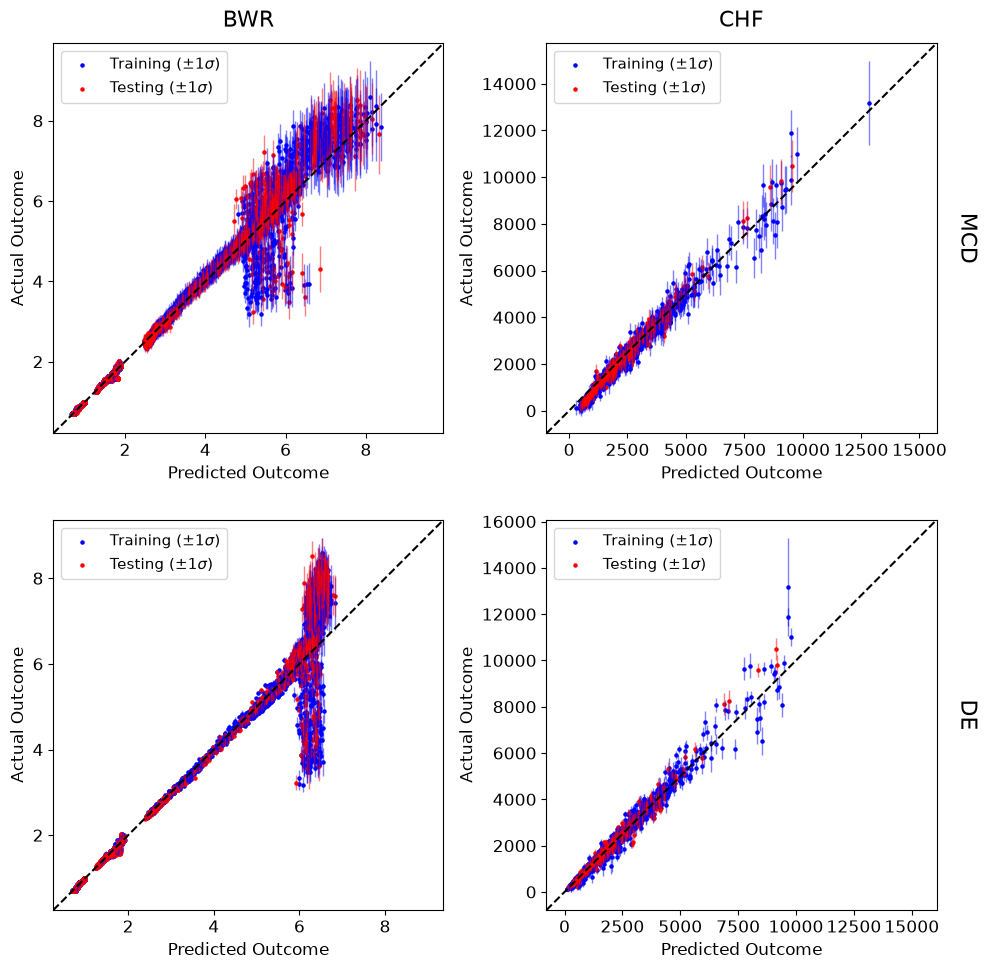

In [35]:
fig, ax = plt.subplots(2, 2, figsize=(10, 10))
pp_bwr.diagonal_validation_plot(ax=ax[0][0], model_type="MCD")   # Turn OFF uncertainty using: `show_uncertainty=False`
pp_chf.diagonal_validation_plot(ax=ax[0][1], model_type="MCD")
pp_bwr.diagonal_validation_plot(ax=ax[1][0], model_type="DE")
pp_chf.diagonal_validation_plot(ax=ax[1][1], model_type="DE")

# Column titles
ax[0][0].set_title("BWR", fontsize=16, pad=12)
ax[0][1].set_title("CHF", fontsize=16, pad=12)

# Row labels
ax[0][1].annotate("MCD", xy=(1.05, 0.5), xycoords="axes fraction", rotation=-90, va="center", ha="left", fontsize=16)
ax[1][1].annotate("DE", xy=(1.05, 0.5), xycoords="axes fraction", rotation=-90, va="center", ha="left", fontsize=16)

fig.tight_layout()

## Validation Plot

For both datasets, notice how MCD has both higher absolute relative error and greater uncertainty.

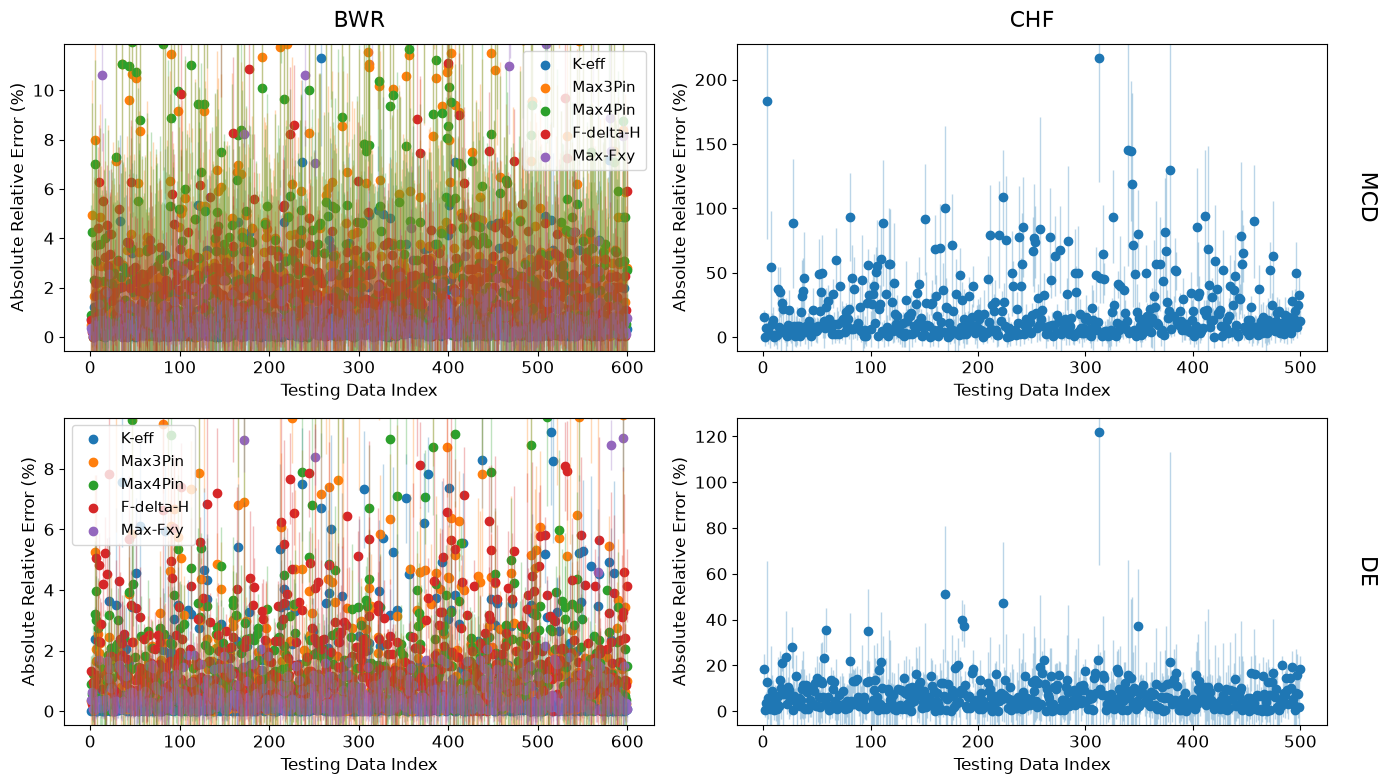

In [36]:
fig, ax = plt.subplots(2, 2, figsize=(14, 8))
pp_bwr.validation_plot(ax=ax[0][0], model_type="MCD")
pp_chf.validation_plot(ax=ax[0][1], model_type="MCD")
pp_bwr.validation_plot(ax=ax[1][0], model_type="DE")
pp_chf.validation_plot(ax=ax[1][1], model_type="DE")

# Column titles
ax[0][0].set_title("BWR", fontsize=16, pad=12)
ax[0][1].set_title("CHF", fontsize=16, pad=12)

# Row labels
ax[0][1].annotate("MCD", xy=(1.05, 0.5), xycoords="axes fraction", rotation=-90, va="center", ha="left", fontsize=16)
ax[1][1].annotate("DE", xy=(1.05, 0.5), xycoords="axes fraction", rotation=-90, va="center", ha="left", fontsize=16)

fig.tight_layout()

## Learning Plot

Since the deep ensemble is a collection of deterministic neural networks, each model holds a learning history, which enables us to visualize the spread of the learning over all the DE members. This is great for noticing potential uncertainty due to overfitting. As individual models become overfit, they begin to follow specific trends or noise in the data. This can go unnoticed in a normal visualization (without UQ) if the overfitting is subtle. However, with a several-member deep ensemble, the disagreement in validation outputs will display a much more distinct visual indication. These demonstration datasets performed quite well, and the CHF data might display potential for slightly overfitting past 100 epochs. For an example of obvious overfitting gone unnoticed, see the [Boiling Water Reactor micro-core notebook](bwr.ipynb#overfit-nnl-deep-ensemble) (bwr.ipynb @ cell #24)
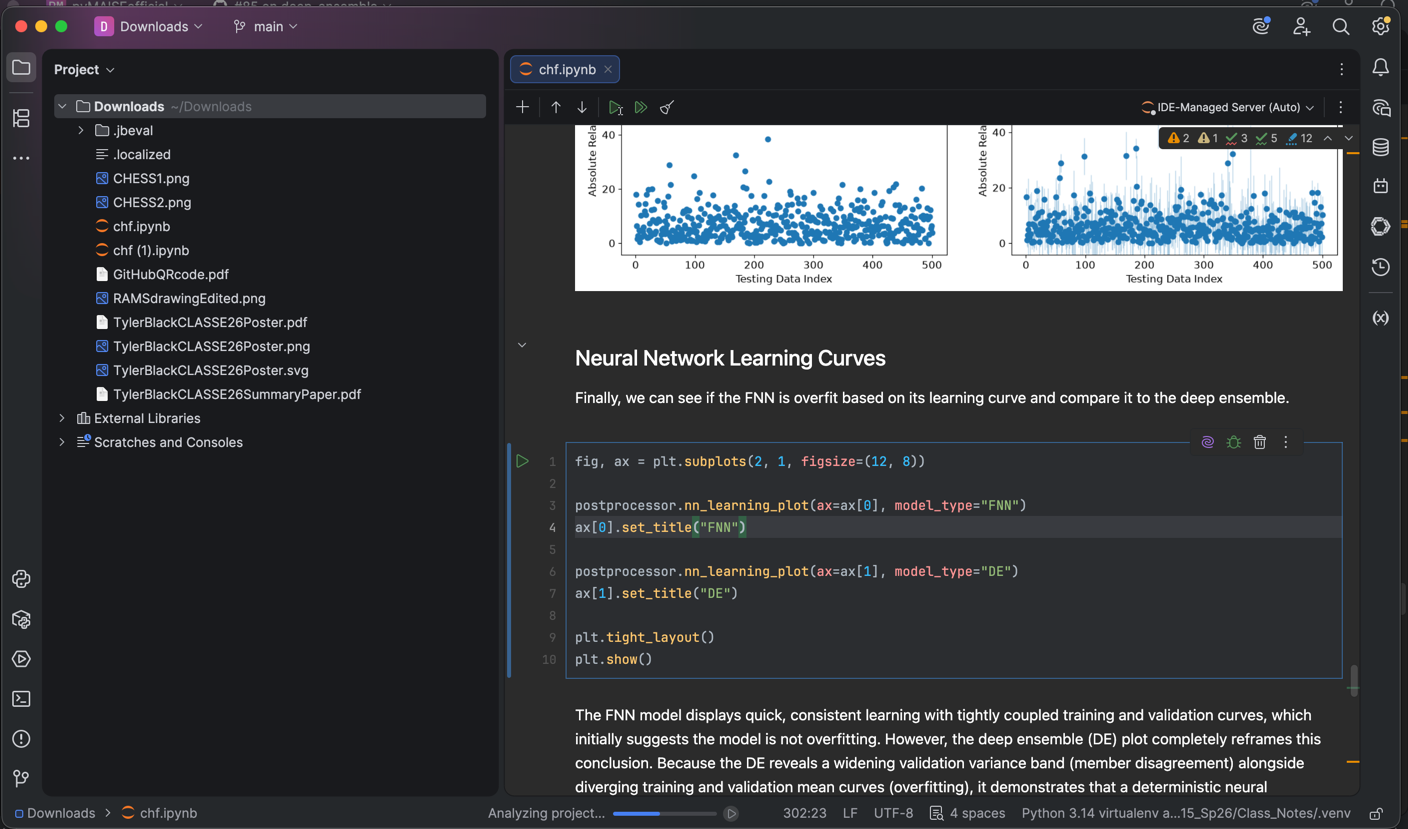

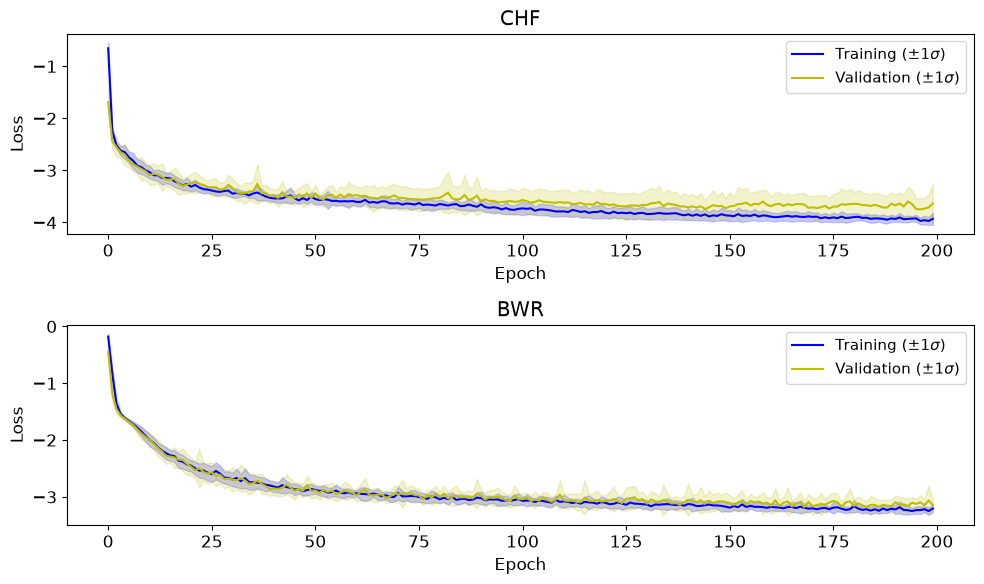

In [37]:
fig, ax = plt.subplots(2, 1, figsize=(10, 6))
pp_chf.nn_learning_plot(ax=ax[0], model_type="DE")
pp_bwr.nn_learning_plot(ax=ax[1], model_type="DE")

ax[0].set_title("CHF")
ax[1].set_title("BWR")
plt.tight_layout()

## Comparing Aleatoric and Epistemic Uncertainty

### Types of Uncertainty
**Aleatoric** uncertainty is the inherent noise in the data, which cannot be reduced by model tuning or additional data. To measure aleatoric uncertainty, the model must be set to use the **Negative Log Likelihood (NLL)** loss function in the model compile parameters (`"loss": "nll"`). The NLL loss function forces the model to minimize loss by increasing uncertainty for incorrect predictions, while rewarding low uncertainty for accurate ones.


**Epistemic** uncertainty is reducible model disagreement or the variance between the models' outputs. A low epistemic uncertainty is generally desirable, and it can be achieved by improving the model's performance during tuning.

In [38]:
MODEL_TYPE = "DE"

Notice that this model has a respectably low and consistent epistemic uncertainty compared to its aleatoric uncertainty.

<Axes: title={'center': 'Epistemic vs Aleatoric Uncertainty per Output'}, ylabel='Normalized Variance (0-1)'>

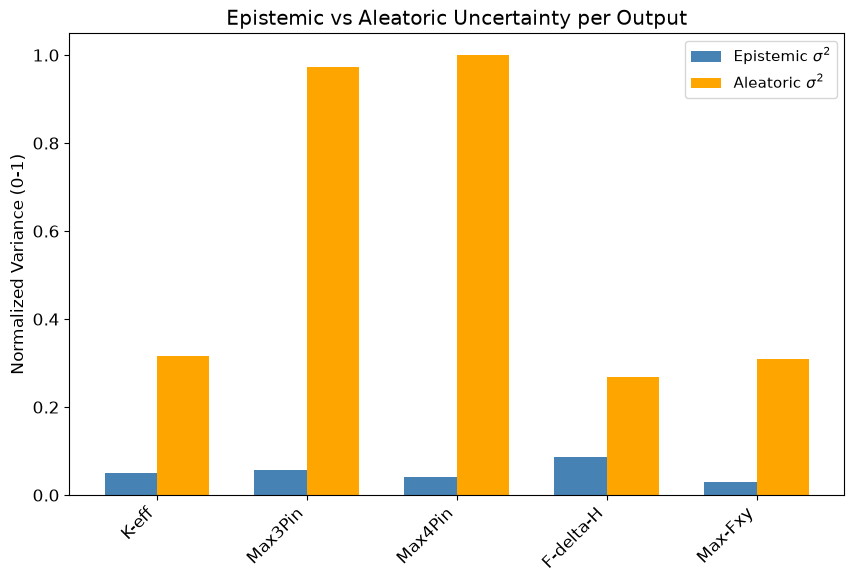

In [39]:
fig, ax = plt.subplots(figsize=(10, 6))
pp_bwr.uncertainty_visualization("epistemic_aleatoric", ax=ax, normalize=True, model_type=MODEL_TYPE)

## Uncertainty by Sorted Predictions

The standard deviation can be visualized at the output value, helping identify the uncertainty at a certain output range. For `Max3Pin`, the DE model becomes increasingly uncertain above an output of $6$.

Reminder: $STD = \sigma = \sqrt{\sigma^2} = \sqrt{Variance}$

<Axes: title={'center': 'Target: Max3Pin'}, xlabel='Sample Index', ylabel='Prediction Value'>

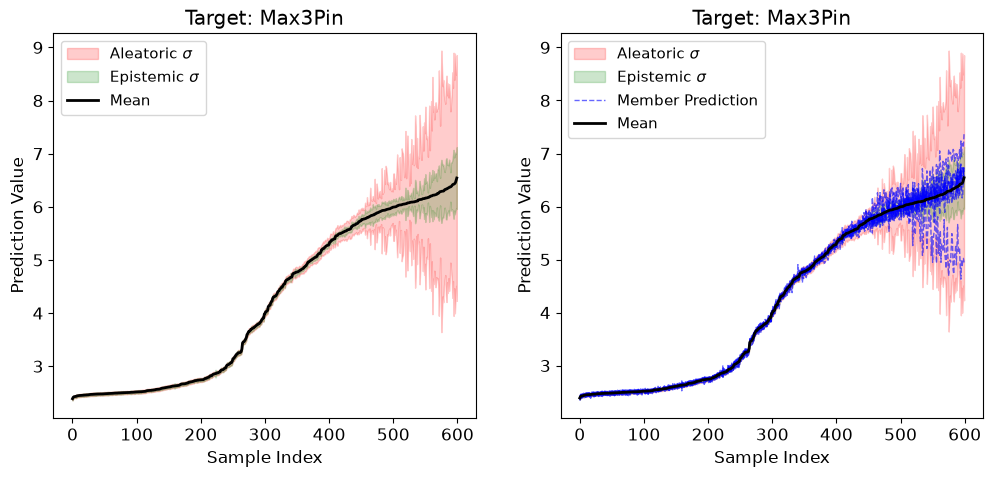

In [40]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
pp_bwr.uncertainty_visualization("sorted_uncertainty", ax=ax[0], feature="Max3Pin", model_type=MODEL_TYPE)
pp_bwr.uncertainty_visualization("sorted_uncertainty", ax=ax[1], feature="Max3Pin", model_type=MODEL_TYPE, show_members=True)

## Data Calibration & Verification

A data subsampling ablation study can be performed using either `sorted_uncertainty` for a single output feature or `epistemic_aleatoric` for all output features. The study decomposes the data into a specified number of sections, which overall communicate the behavior of the aleatoric and epistemic uncertainty. Ideally, epistemic uncertainty should steadily decrease as the subsample size increases, because more data is being presented to the model. Also ideally, the aleatoric uncertainty should stay steady across all subsamples, since the inherent noise should not change based on the number of randomized samples.

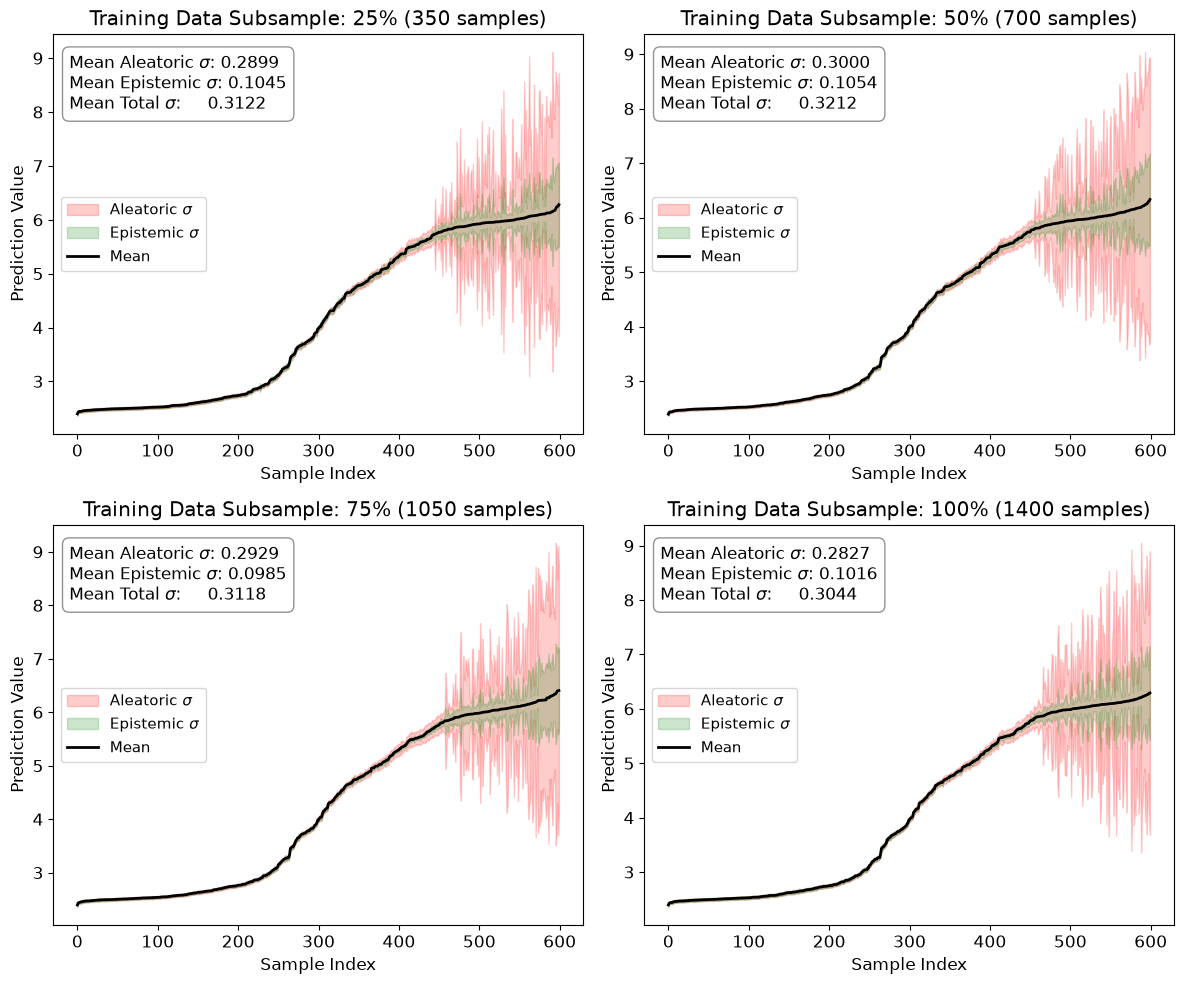

In [41]:
fig, axes = pp_bwr.uncertainty_visualization(
    "data_calibration",
    sections=4,
    plot_type="sorted_uncertainty",
    feature="Max3Pin",
    model_type=MODEL_TYPE
)

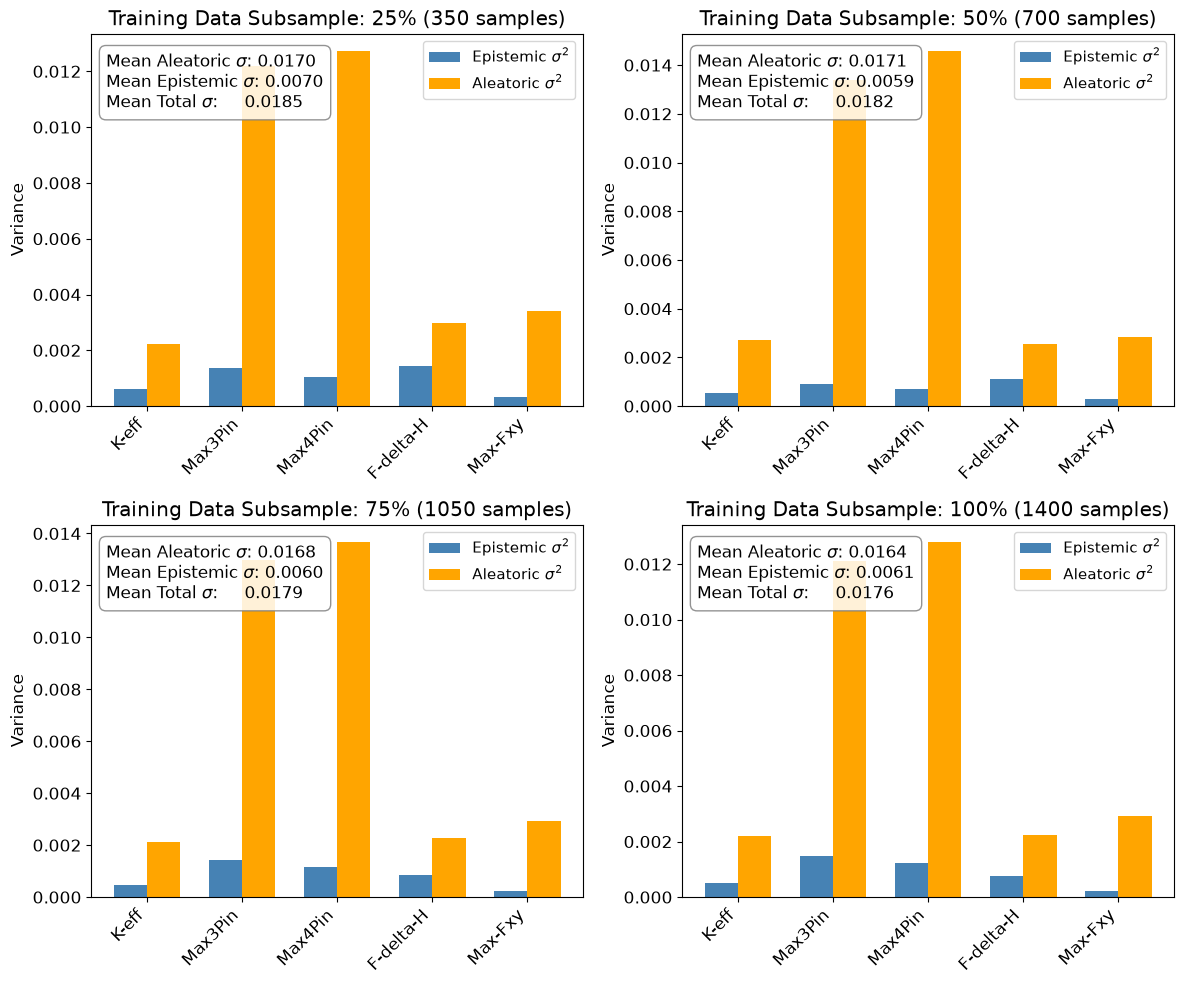

In [42]:
fig, axes = pp_bwr.uncertainty_visualization(
    "data_calibration",
    sections=4,
    plot_type="epistemic_aleatoric",
    model_type=MODEL_TYPE
)